# 03 - Time Window Study

Exhaustive benchmark of every model across multiple lookback windows, with the selected window and per-window leaderboard written to `debug_exports`.

NOTE: Run this notebook LAST — it performs the final time-window sweep after feature importance, an 80-day benchmark, and 3-day forecast steps have been completed.

In [1]:
import os
import json
import sys
from pathlib import Path

# Force CPU-only for this run (disable CUDA GPUs)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
load_dotenv(str(ROOT / ".env"), override=False)

from src.features.feature_catalog import get_feature_catalog
from src.models.evaluate import evaluate_forecast, per_horizon_metrics
from src.models.model_configs import MODEL_CONFIGS
from src.models.train import train_model
from src.utils.mongo_client import get_database

sns.set_theme(style="whitegrid")

ARTIFACTS_DIR = ROOT / "debug_exports"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("aqi_features_rawalpindi is empty")

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Use selected top features (from feature importance) when available
feature_cols_all = [column for column in get_feature_catalog() if column in data.columns]
# Try to load top features produced by `05_feature_importance.ipynb`
try:
    top_features_payload = json.loads((ARTIFACTS_DIR / "top_features.json").read_text(encoding="utf-8"))
    feature_cols = [f for f in top_features_payload.get("features", []) if f in data.columns] or feature_cols_all
except Exception:
    feature_cols = feature_cols_all

# Build shortlist of best models from the model benchmark (prefer simple ML models)
# Simple ML types exclude recurrent/network models like 'gru' and 'lstm'
try:
    bench_path = ARTIFACTS_DIR / "model_benchmark_metrics.csv"
    if bench_path.exists():
        bench_df = pd.read_csv(bench_path)
        bench_df = bench_df.dropna(subset=["rmse"]).copy()
        bench_df = bench_df[~bench_df["type"].isin(["gru", "lstm"])].copy()
        shortlist_models = bench_df.sort_values(["rmse", "model"]).head(4)["model"].tolist()
    else:
        shortlist_models = [c.name for c in MODEL_CONFIGS if c.type not in ("gru", "lstm")][:4]
except Exception:
    shortlist_models = [c.name for c in MODEL_CONFIGS if c.type not in ("gru", "lstm")][:4]

window_days_list = [7, 30, 60, 90, 180, 365]
horizon = 72


def build_window_frame(frame: pd.DataFrame, days: int) -> pd.DataFrame:
    latest_timestamp = frame["timestamp"].max()
    window_start = latest_timestamp - pd.Timedelta(days=days)
    return frame.loc[frame["timestamp"] >= window_start].sort_values("timestamp").reset_index(drop=True)


def prepare_training_matrices(window_frame: pd.DataFrame):
    if len(window_frame) <= horizon:
        return None, None, None

    target = window_frame["european_aqi"].astype(float)
    feature_frame = window_frame[feature_cols].apply(pd.to_numeric, errors="coerce").ffill().fillna(0.0)
    feature_frame = feature_frame.loc[:, feature_frame.nunique(dropna=True) > 1].copy()
    if feature_frame.empty or len(feature_frame) <= horizon:
        return None, None, None

    y = pd.DataFrame([target.iloc[index : index + horizon].values for index in range(len(target) - horizon)])
    x = feature_frame.iloc[: len(y)].copy()
    if x.empty:
        return None, None, None

    return x, y, list(x.columns)

2026-05-30 15:11:31.524122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780135891.542689  108008 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780135891.548531  108008 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780135891.561568  108008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780135891.561590  108008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780135891.561591  108008 computation_placer.cc:177] computation placer alr

In [2]:
results = []
for days in window_days_list:
    window_frame = build_window_frame(data, days)
    if len(window_frame) < horizon + 200:
        results.append({"window_days": days, "rows": len(window_frame), "note": "insufficient_rows"})
        continue

    x, y, used_features = prepare_training_matrices(window_frame)
    if x is None or y is None:
        results.append({"window_days": days, "rows": len(window_frame), "note": "no_features_after_filter"})
        continue

    # Iterate only over shortlisted best models (from benchmark) to evaluate per-window performance
    for model_name in shortlist_models:
        config = next((c for c in MODEL_CONFIGS if c.name == model_name), None)
        if config is None:
            results.append({"window_days": days, "model": model_name, "note": "config_not_found"})
            continue
        try:
            model, preds, y_true = train_model(config, x, y, horizon=horizon)
            metrics = evaluate_forecast(y_true, preds)
            metrics.update(per_horizon_metrics(y_true, preds))
            results.append(
                {
                    "window_days": days,
                    "model": config.name,
                    "type": config.type,
                    "rows": len(window_frame),
                    "rows_after_prep": len(x),
                    "features_used": len(used_features),
                    **metrics,
                }
            )
        except Exception as exc:
            results.append(
                {
                    "window_days": days,
                    "model": config.name,
                    "type": config.type,
                    "rows": len(window_frame),
                    "rows_after_prep": len(x),
                    "features_used": len(used_features),
                    "error": str(exc),
                }
            )

results_df = pd.DataFrame(results)
if results_df.empty:
    raise ValueError("No model-window benchmark results were produced")

results_df = results_df.sort_values(["window_days", "rmse", "model"], na_position="last").reset_index(drop=True)
results_path = ARTIFACTS_DIR / "time_window_model_metrics.csv"
results_df.to_csv(results_path, index=False)

valid_results = results_df.dropna(subset=["rmse"]).copy()
if valid_results.empty:
    raise ValueError("All model-window benchmark runs failed")

window_summary = (
    valid_results.groupby("window_days")
    .agg(
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        best_rmse=("rmse", "min"),
        best_model=("model", lambda series: series.iloc[0]),
        model_count=("model", "count"),
    )
    .reset_index()
)

best_window_row = window_summary.sort_values(["median_rmse", "mean_rmse"]).iloc[0]
best_window = int(best_window_row["window_days"])

with open(ARTIFACTS_DIR / "best_window_days.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "best_window_days": best_window,
            "selection_metric": "median_rmse",
            "evaluated_windows": window_days_list,
        },
        handle,
        indent=2,
    )

display(results_df.head(30))
display(window_summary.sort_values("window_days"))

print(f"Saved {results_path}")
print(f"Best window: {best_window} days")

,window_days,rows,note,model,type,rows_after_prep,features_used,rmse,mae,r2,rmse_24h,rmse_48h,rmse_72h
0,7,169,insufficient_rows,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,30,567,NaN,catboost,cat,495.0,17.0,50.579239,45.314592,0.0,64.264068,51.142589,20.022296
2,30,567,NaN,extra_trees,extra,495.0,17.0,55.028692,50.032708,0.0,73.305728,48.619389,12.415440
3,30,567,NaN,random_forest,rf,495.0,17.0,55.948816,46.013716,0.0,71.359609,51.072414,10.922229
4,30,567,NaN,xgboost,xgb,495.0,17.0,66.773910,50.015311,0.0,60.613590,61.702053,20.658814
5,60,567,NaN,catboost,cat,495.0,17.0,50.579239,45.314592,0.0,64.264068,51.142589,20.022296
6,60,567,NaN,extra_trees,extra,495.0,17.0,54.611473,49.713499,0.0,72.749408,46.853641,13.559777
7,60,567,NaN,random_forest,rf,495.0,17.0,55.763596,45.540399,0.0,73.080310,48.707502,10.428257
8,60,567,NaN,xgboost,xgb,495.0,17.0,66.773910,50.015311,0.0,60.613590,61.702053,20.658814
9,90,567,NaN,catboost,cat,495.0,17.0,50.579239,45.314592,0.0,64.264068,51.142589,20.022296


,window_days,mean_rmse,median_rmse,best_rmse,best_model,model_count
0,30,57.082664,55.488754,50.579239,catboost,4
1,60,56.932054,55.187534,50.579239,catboost,4
2,90,56.859232,55.041890,50.579239,catboost,4
3,180,56.816931,54.957289,50.579239,catboost,4
4,365,56.576441,54.476309,50.579239,catboost,4


Saved /home/mwasifshakeel/Videos/pearls-aqi-predictor/debug_exports/time_window_model_metrics.csv
Best window: 365 days


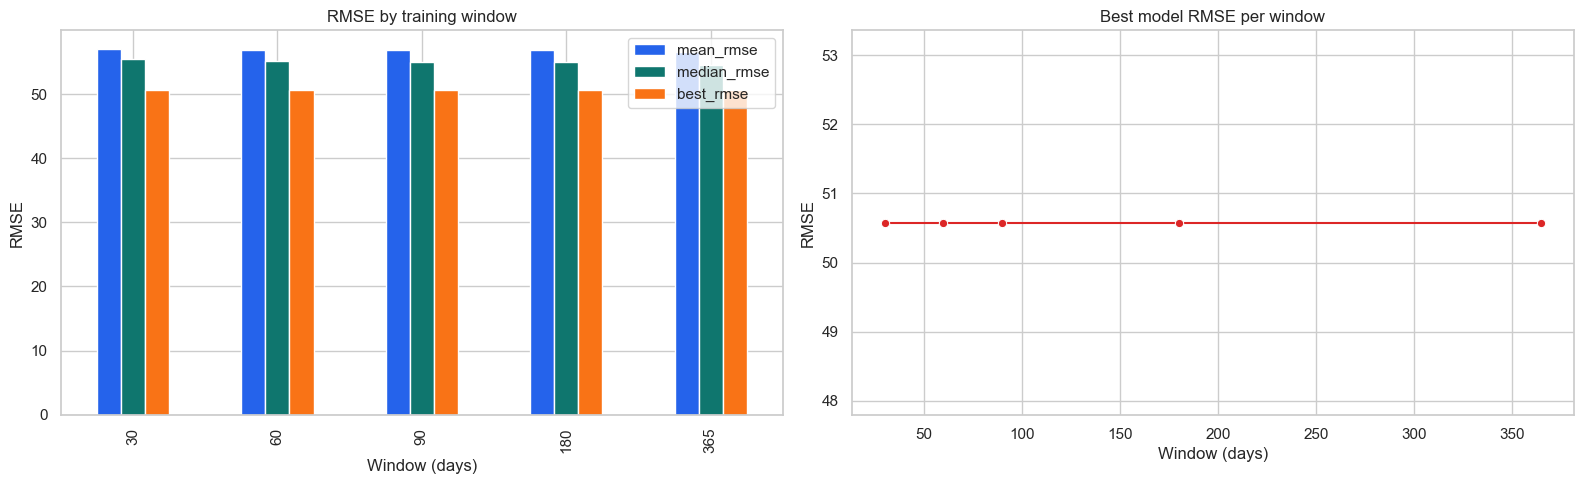

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

window_summary.sort_values("window_days").plot(
    x="window_days",
    y=["mean_rmse", "median_rmse", "best_rmse"],
    kind="bar",
    ax=axes[0],
    color=["#2563eb", "#0f766e", "#f97316"],
)
axes[0].set_title("RMSE by training window")
axes[0].set_xlabel("Window (days)")
axes[0].set_ylabel("RMSE")
axes[0].legend(loc="best")

best_by_window = valid_results.sort_values("rmse").groupby("window_days").first().reset_index()
sns.lineplot(data=best_by_window, x="window_days", y="rmse", marker="o", ax=axes[1], color="#dc2626")
axes[1].set_title("Best model RMSE per window")
axes[1].set_xlabel("Window (days)")
axes[1].set_ylabel("RMSE")

plt.tight_layout()

No hourly gaps detected in the loaded series.


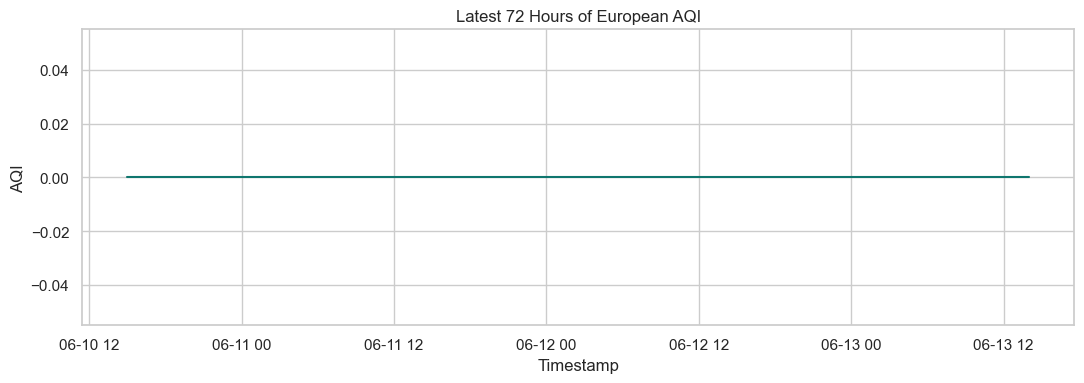

In [4]:
timestamp_diff_hours = data["timestamp"].diff().dt.total_seconds().div(3600)
gap_counts = timestamp_diff_hours[timestamp_diff_hours > 1].dropna().round().value_counts().sort_index()

if gap_counts.empty:
    print("No hourly gaps detected in the loaded series.")
else:
    display(gap_counts.to_frame(name="gap_count"))

recent_slice = data.tail(72).copy()
fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=recent_slice, x="timestamp", y="european_aqi", ax=ax, color="#0f766e")
ax.set_title("Latest 72 Hours of European AQI")
ax.set_xlabel("Timestamp")
ax.set_ylabel("AQI")
plt.tight_layout()

In [5]:
selected_window_results = valid_results[valid_results["window_days"] == best_window].sort_values("rmse").reset_index(drop=True)
display(
    selected_window_results[
        ["window_days", "model", "type", "rmse", "mae", "r2", "rows_after_prep", "features_used"]
    ]
)

print(f"Best-window leaderboard is based on {best_window} days and has been saved to debug_exports.")

,window_days,model,type,rmse,mae,r2,rows_after_prep,features_used
0,365,catboost,cat,50.579239,45.314592,0.0,495.0,17.0
1,365,extra_trees,extra,53.705159,48.691475,0.0,495.0,17.0
2,365,random_forest,rf,55.247458,44.730940,0.0,495.0,17.0
3,365,xgboost,xgb,66.773910,50.015311,0.0,495.0,17.0


Best-window leaderboard is based on 365 days and has been saved to debug_exports.
